In [1]:
import os
import sys
import json
import argparse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

from glob import glob
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm.second_level import make_second_level_design_matrix
from nilearn.image import threshold_img
from nilearn.glm import threshold_stats_img

/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '


In [2]:
from nilearn import plotting, datasets, surface

# for plotting slices
mni152_template = datasets.load_mni152_template(resolution=1)
# for plotting on surface
fsaverage = datasets.fetch_surf_fsaverage('fsaverage')

In [19]:
task_label = 'stgrid'
contrast_label = 'sound'
fwhm = 3 # 1.5
space_label = 'MNI152NLin2009cAsym'

# define data directories
bidsroot = os.path.join('/ix1/bchandrasekaran/krs228/data/', 
                        'FLT/',
                        'data_denoised',
                       )
nilearn_dir = os.path.join(bidsroot, 'derivatives', 'nilearn')

# define first-level directory where group-level inputs will be pulled from
l1_dir = os.path.join(nilearn_dir, f'bids-deriv_level-1_fwhm-{fwhm:.02f}')

# create output directory
group_out_dir = os.path.join(nilearn_dir, f'level-group_fwhm-{fwhm:.02f}')
if not os.path.exists(group_out_dir):
        os.makedirs(group_out_dir)

# Second-level analyses

Based on [nilearn documentation](https://nilearn.github.io/stable/auto_examples/05_glm_second_level/plot_thresholding.html#statistical-testing-of-a-second-level-analysis)

### Build the group-level design matrix

#### Read the `participants.tsv` file from the BIDS root directory

In [35]:
participants_fpath = os.path.join(bidsroot, 'participants.tsv')
participants_df = pd.read_csv(participants_fpath, sep='\t')

# subjects to ignore (not fully processed, etc.)
ignore_subs = ['sub-FLT27',
               'sub-FLT07', # bad QA 11/14/23
               'sub-FLT11', 'sub-FLT12', 'sub-FLT20', 'sub-FLT30',
               #'sub-FLT02', 'sub-FLT04', 'sub-FLT18', 'sub-FLT19',
              ]
participants_df.drop(participants_df[participants_df.participant_id.isin(ignore_subs)].index, inplace=True)

# re-sort by participant ID
participants_df.sort_values(by=['participant_id'], ignore_index=True, inplace=True)

In [36]:
print(participants_df)

   participant_id  age sex         group  FFR_id
0       sub-FLT02   21   F  non-Mandarin  1002.0
1       sub-FLT03   25   F      Mandarin  2002.0
2       sub-FLT04   21   F  non-Mandarin  1003.0
3       sub-FLT05   26   M      Mandarin  3010.0
4       sub-FLT06   21   F  non-Mandarin  3001.0
5       sub-FLT08   23   F      Mandarin  2005.0
6       sub-FLT09   30   F  non-Mandarin  3002.0
7       sub-FLT10   23   F      Mandarin  2006.0
8       sub-FLT13   23   F  non-Mandarin  3005.0
9       sub-FLT14   23   M  non-Mandarin  3006.0
10      sub-FLT15   22   M      Mandarin  2010.0
11      sub-FLT17   29   F      Mandarin     NaN
12      sub-FLT18   24   M      Mandarin  2016.0
13      sub-FLT19   24   M      Mandarin  2018.0
14      sub-FLT21   21   M      Mandarin  2011.0
15      sub-FLT22   41   F      Mandarin  2017.0
16      sub-FLT23   26   F      Mandarin  2013.0
17      sub-FLT24   20   M      Mandarin  2015.0
18      sub-FLT25   19   F  non-Mandarin  1013.0
19      sub-FLT26   

In [37]:
# create group-specific lists of subject IDs
sub_list_mand = list(participants_df.participant_id[participants_df.group=='Mandarin'])
sub_list_nman = list(participants_df.participant_id[participants_df.group=='non-Mandarin'])

In [38]:
print(sub_list_mand)

['sub-FLT03', 'sub-FLT05', 'sub-FLT08', 'sub-FLT10', 'sub-FLT15', 'sub-FLT17', 'sub-FLT18', 'sub-FLT19', 'sub-FLT21', 'sub-FLT22', 'sub-FLT23', 'sub-FLT24', 'sub-FLT26']


In [39]:
print(sub_list_nman)

['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT13', 'sub-FLT14', 'sub-FLT25', 'sub-FLT28']


#### Create design matrixes

In [40]:
# get participant IDs and their group labels
subjects_label = list(participants_df.participant_id)
groups_label = list(participants_df.group)

# make new dataframe from the group labels
design_mat_groupdiff = pd.DataFrame({'Mand': groups_label,
                                     'NMan': groups_label,
                                    }
                                   )
# convert to 1s and 0s for each group as appropriate
design_mat_groupdiff['Mand'].loc[design_mat_groupdiff['Mand'] == 'Mandarin'] = 1
design_mat_groupdiff['Mand'].loc[design_mat_groupdiff['Mand'] == 'non-Mandarin'] = 0
design_mat_groupdiff['NMan'].loc[design_mat_groupdiff['NMan'] == 'Mandarin'] = 0
design_mat_groupdiff['NMan'].loc[design_mat_groupdiff['NMan'] == 'non-Mandarin'] = 1
design_mat_groupdiff = design_mat_groupdiff.astype('int')
print(design_mat_groupdiff)

    Mand  NMan
0      0     1
1      1     0
2      0     1
3      1     0
4      0     1
5      1     0
6      0     1
7      1     0
8      0     1
9      0     1
10     1     0
11     1     0
12     1     0
13     1     0
14     1     0
15     1     0
16     1     0
17     1     0
18     0     1
19     1     0
20     0     1


# event-sound

In [44]:
# get the beta map for the contrast of interest for each subject
l1_fnames = [sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/'+
                         f'run-all_event-{contrast_label}/'+
                         f'*contrast-stim*_stat-effect_statmap.nii.gz')
                   )[0] for sub_id in subjects_label]


In [55]:
title = f'STgrid {contrast_label}'

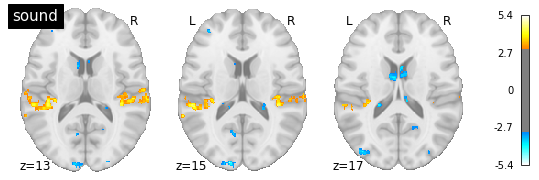

In [53]:
# thresholds for second-level stats images
alpha = 0.05
cthresh = 10
cluster_correct = None # 'fdr', None

#fig, ax = plt.subplots(16, 1,figsize=(5,15), dpi=300)

z_fpath = os.path.join(group_out_dir, f'contrast-{contrast_label}.nii.gz')


second_level_model = SecondLevelModel().fit(l1_fnames, # smoothing_fwhm=2*fwhm
                                            design_matrix=design_mat_groupdiff)

z_map = second_level_model.compute_contrast(second_level_contrast=[1, 1], 
                                            output_type='z_score')
nib.save(z_map, z_fpath)

thresholded_map, zthresh = threshold_stats_img(
                        z_fpath, # z_map,
                        alpha=alpha,
                        height_control=cluster_correct,
                        cluster_threshold=cthresh,
                        two_sided=True,
                        )

plotting.plot_stat_map( thresholded_map, # thresholded_map, z_fpath
                        threshold=zthresh, # zthresh,
                        bg_img=mni152_template,
                        black_bg=False,
                        cut_coords=[13, 15, 17,],
                        display_mode='z',
                        title=title,
                        #axes=ax[sx]
                    )


In [54]:
zthresh

3.0

/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



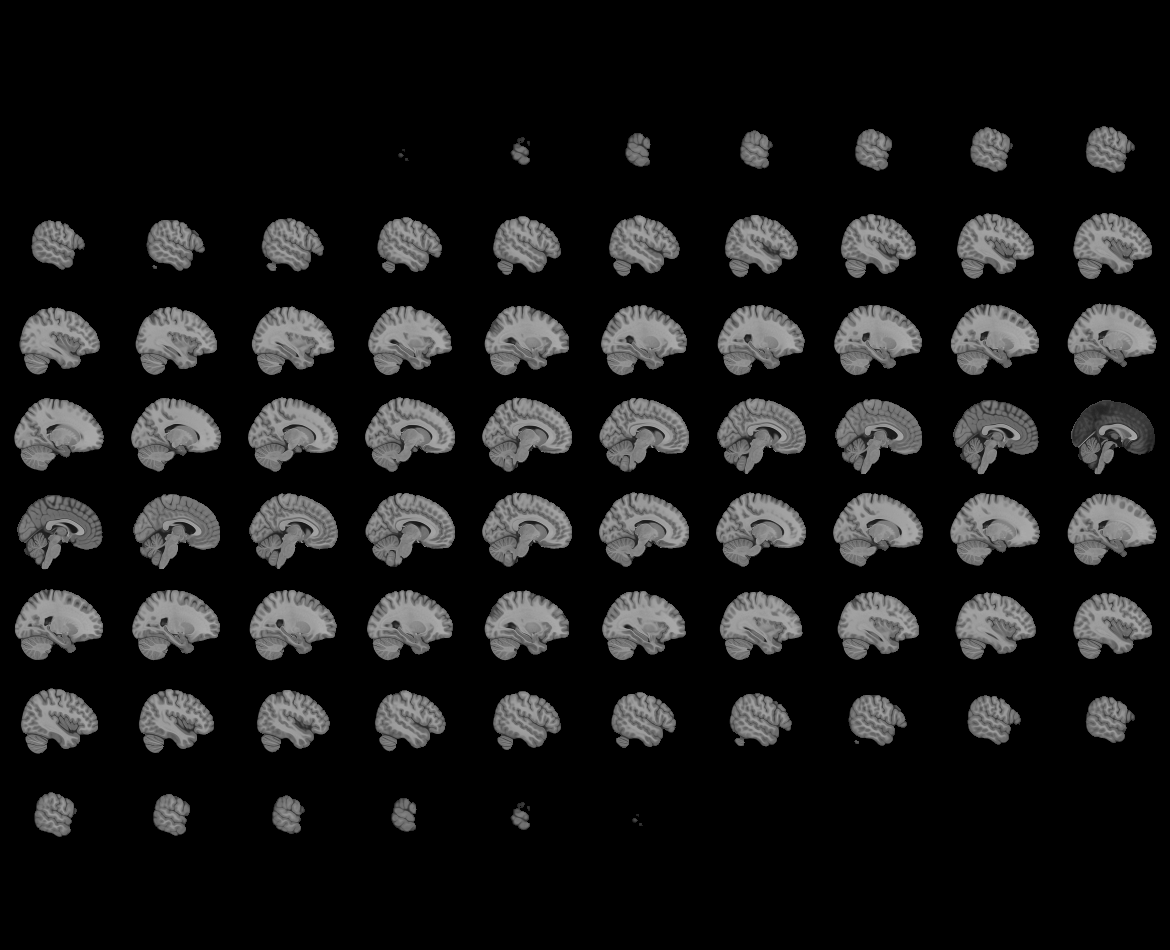
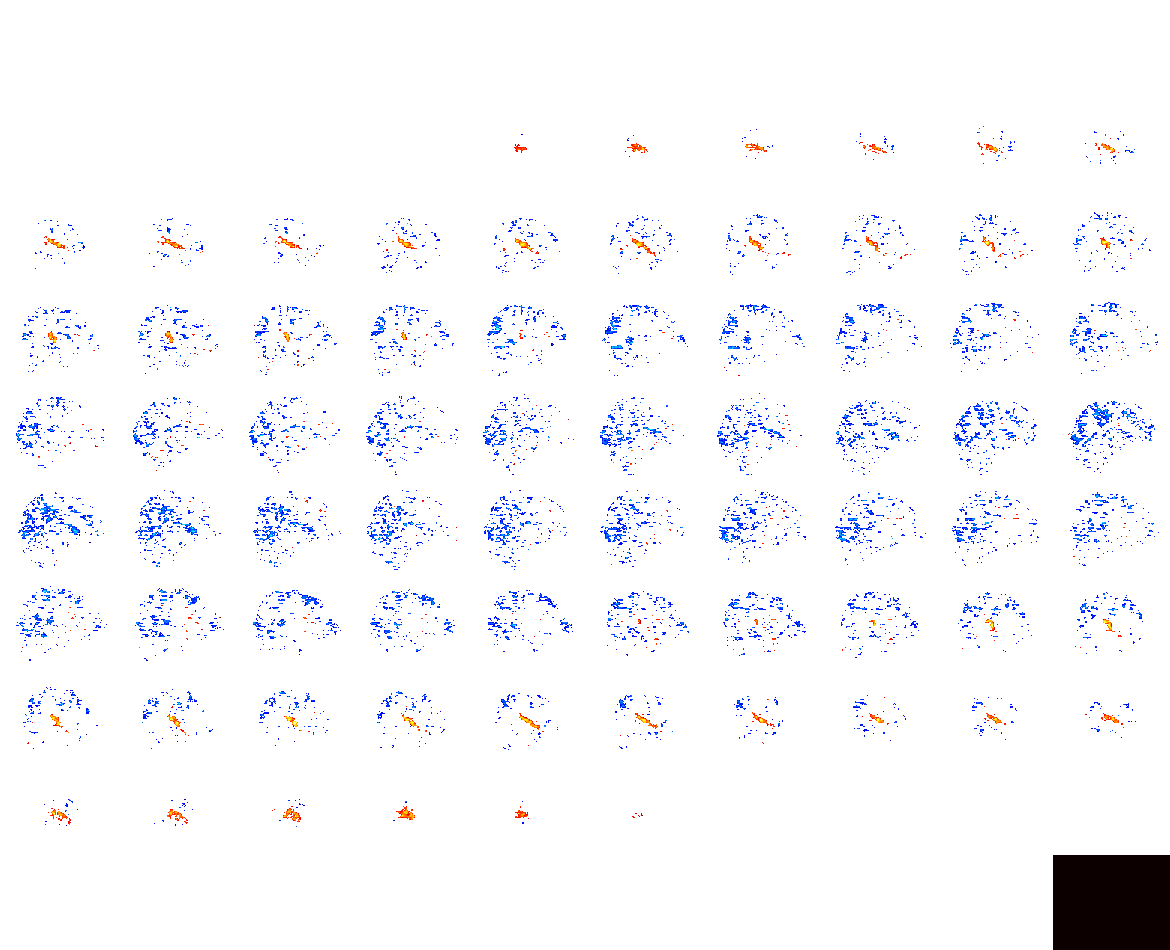

In [56]:
plotting.view_img(z_fpath, # thresholded_map, 
                  threshold=1.96, # zthresh,
                  title=title)

## test single sub

In [29]:
sub_id = 'FLT03'
fpath = os.path.join(l1_dir,
                     f'sub-{sub_id}_space-MNI152NLin2009cAsym/',
                     'run-all_event-sound',
                     f'sub-{sub_id}_task-stgrid_fwhm-{fwhm:.01f}_contrast-stim_stat-z_statmap.nii.gz')

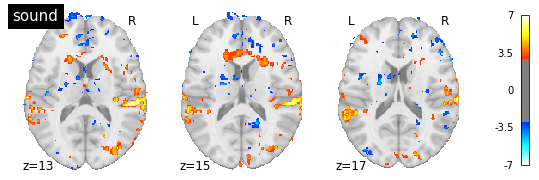

In [34]:
plotting.plot_stat_map( fpath, # thresholded_map, 
                        threshold=3, # zthresh,
                        bg_img=mni152_template,
                        black_bg=False,
                        cut_coords=[13, 15, 17,],
                        display_mode='z',
                        title=contrast_label,
                        #axes=ax[sx]
                    )

/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



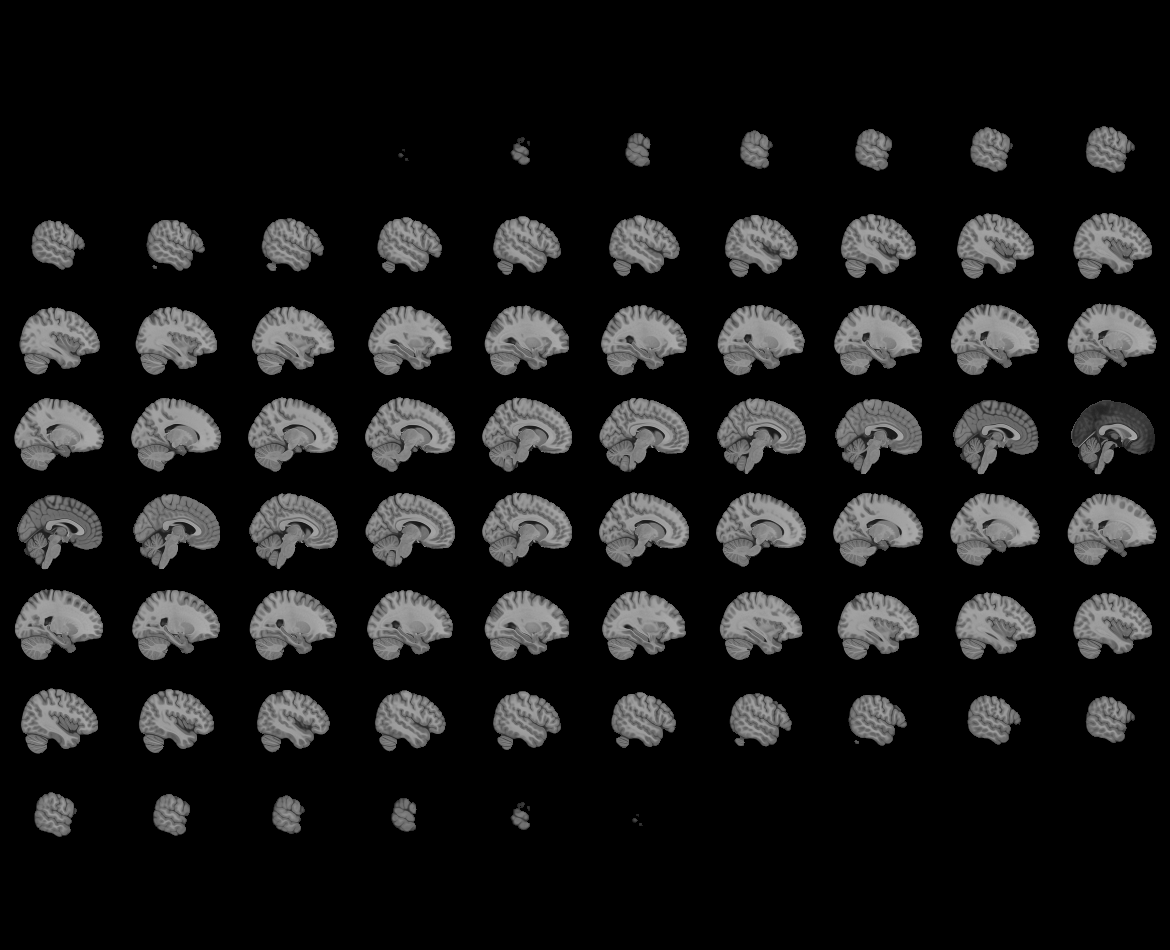
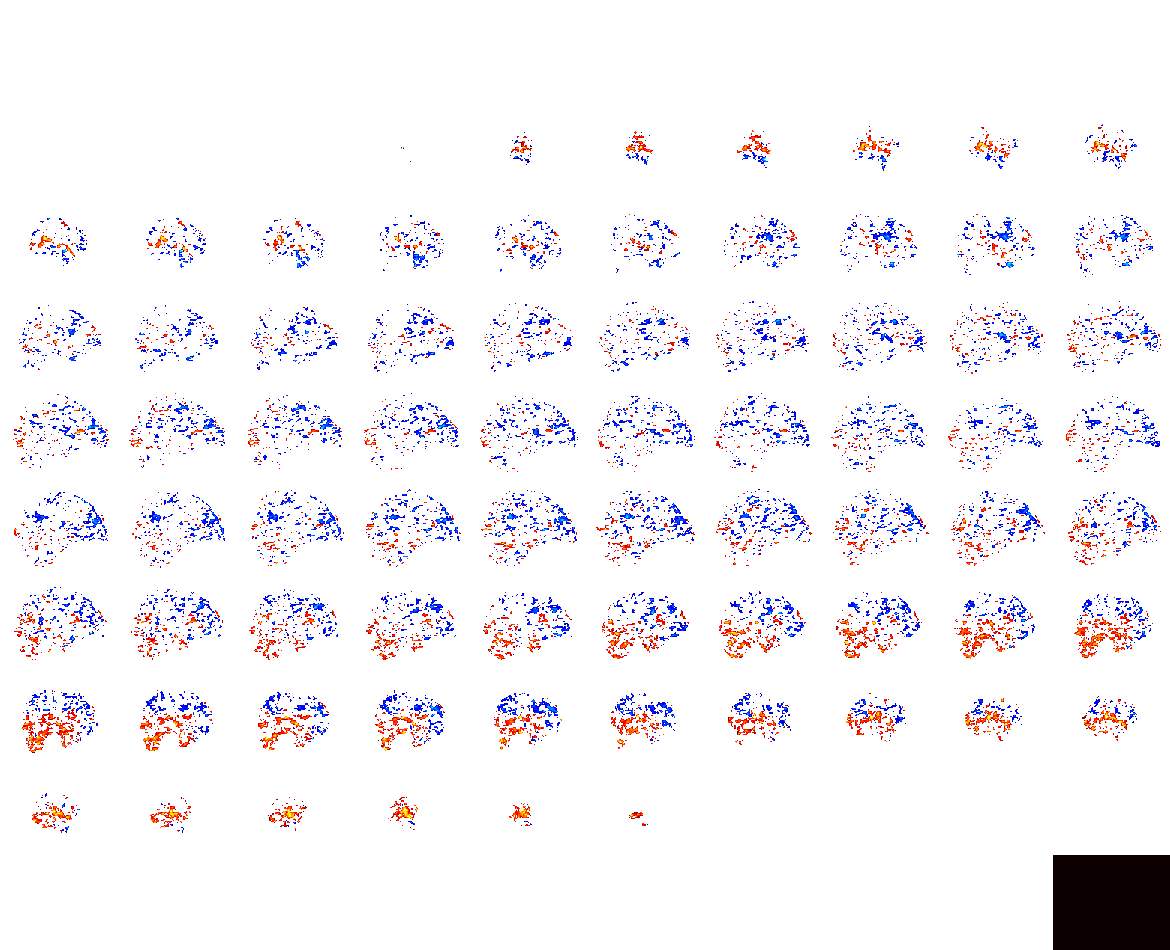

In [30]:
plotting.view_img(fpath, threshold=2)

# event-block_stim

## All contrasts – All participants

### Get files

In [72]:
# get the beta map for the contrast of interest for each subject
fnames_dict = {}

for sx in range(16):
    stimlabel = f'stim{sx+1:02d}'
    l1_fnames = [sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/'+
                             'run-all_event-block_stim/'+
                             f'*contrast-{stimlabel}*_stat-effect_statmap.nii.gz')
                       )[0] for sub_id in subjects_label]
    fnames_dict[stimlabel] = l1_fnames

In [74]:
fnames_dict.keys()

dict_keys(['stim01', 'stim02', 'stim03', 'stim04', 'stim05', 'stim06', 'stim07', 'stim08', 'stim09', 'stim10', 'stim11', 'stim12', 'stim13', 'stim14', 'stim15', 'stim16'])

/scratch/slurm-4692925/ipykernel_17643/235510644.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


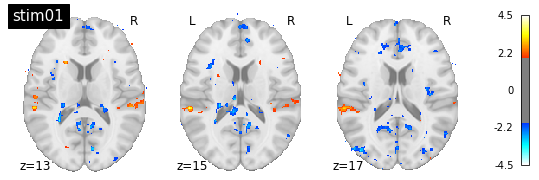

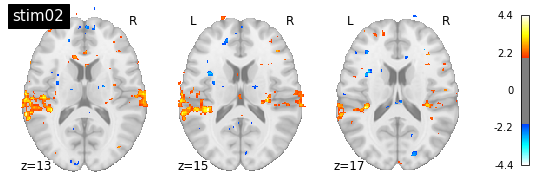

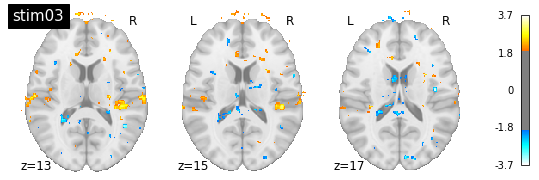

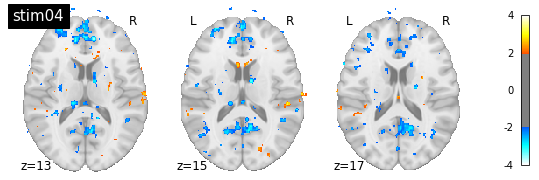

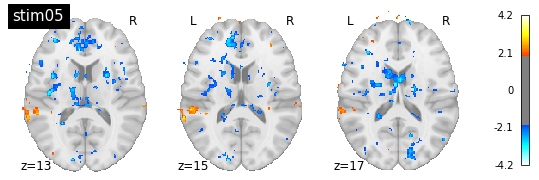

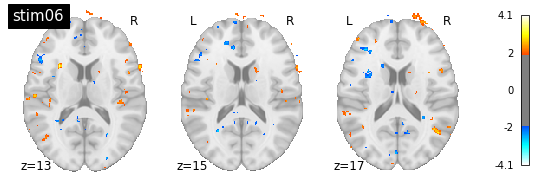

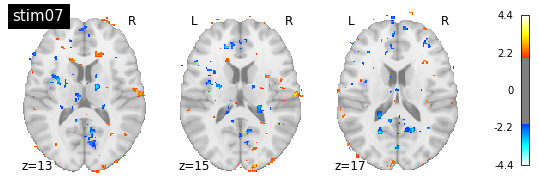

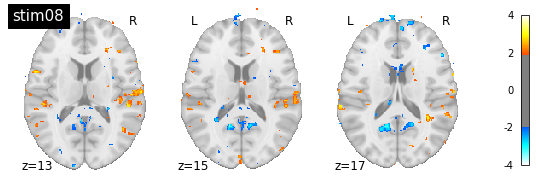

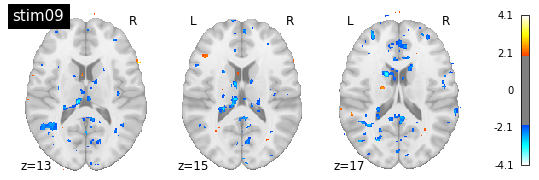

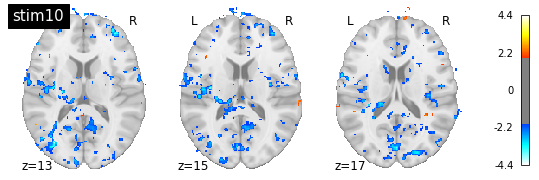

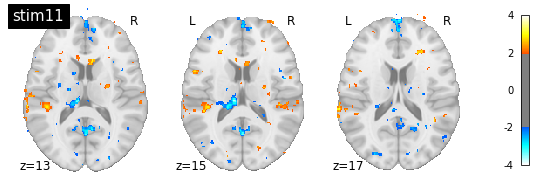

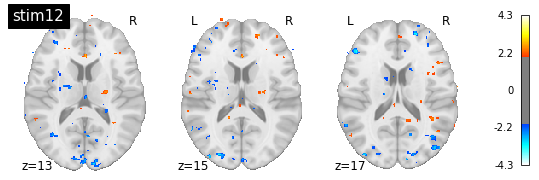

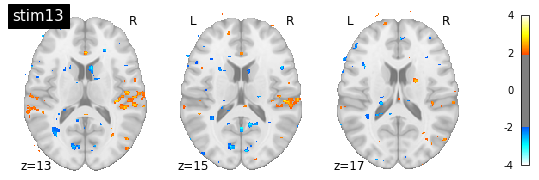

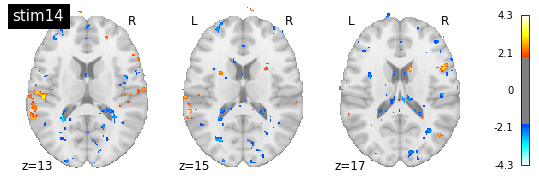

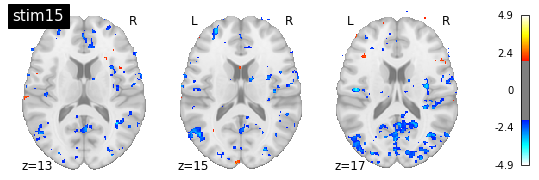

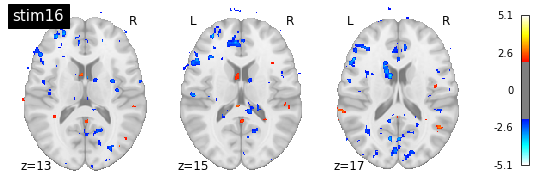

In [91]:
# thresholds for second-level stats images
alpha = 0.05
cthresh = 0 # 10
cluster_correct = None # 'fdr'

#fig, ax = plt.subplots(16, 1,figsize=(5,15), dpi=300)

for sx, stim in enumerate(fnames_dict):
    l1_fnames = fnames_dict[stim]
    z_fpath = os.path.join(group_out_dir, f'contrast-{stim}.nii.gz')
    
    '''
    second_level_model = SecondLevelModel(smoothing_fwhm=2*fwhm).fit(l1_fnames, 
                                                                     design_matrix=design_mat_groupdiff)

    z_map = second_level_model.compute_contrast(second_level_contrast=[1, 1], 
                                                output_type='z_score')
    nib.save(z_map, z_fpath)
    '''
    thresholded_map, zthresh = threshold_stats_img(
                            z_fpath, # z_map,
                            alpha=alpha,
                            height_control=cluster_correct,
                            cluster_threshold=cthresh,
                            two_sided=True,
                            )
    
    plotting.plot_stat_map( z_fpath, # thresholded_map, 
                            threshold=1.96, # zthresh,
                            bg_img=mni152_template,
                            black_bg=False,
                            cut_coords=[13, 15, 17,],
                            display_mode='z',
                            title=stim,
                            #axes=ax[sx]
                        )
    fig.tight_layout()

## Single contrast – All participants

### Get files

In [43]:
# get the beta map for the contrast of interest for each subject

l1_fnames = [sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/'+
                           'run-all_event-block_stim/'+
                           f'*task-{task_label}*_stat-effect_statmap.nii.gz'))[0] for sub_id in subjects_label]

In [45]:
len(l1_fnames)

21

#### Using combined GLM

In [63]:
# create a model object
second_level_model = SecondLevelModel(smoothing_fwhm=2*fwhm).fit(l1_fnames, design_matrix=design_mat_groupdiff)

# fit the model with our contrast of interest
z_map = second_level_model.compute_contrast(second_level_contrast=[1, 1,], output_type='z_score')

In [64]:
# threshold the second-level stats image
alpha = 0.05
cthresh = 0 # 10
cluster_correct = None # 'fdr'

thresholded_map, zthresh = threshold_stats_img(
                            z_map,
                            alpha=alpha,
                            height_control=cluster_correct,
                            cluster_threshold=cthresh,
                            two_sided=True,
                        )

In [ ]:
'''
z_fpath   = os.path.join(group_out_dir,
                         'group-Mand_space-{}_contrast-{}_LSS_map-zstat.nii.gz'.format(space_label, contrast_label))
thr_fpath = os.path.join(group_out_dir,
                         'group-Mand_space-{}_contrast-{}_LSS_alpha-{}_correct-{}_cthresh-{}_map-zstat.nii.gz'.format(space_label, contrast_label, 
                                                                                                                  alpha, cluster_correct, cthresh))

nib.save(z_map, z_fpath)
nib.save(thresholded_map, thr_fpath)
'''

In [53]:
plot_title = ('Group (n=%d)\n'
              'p < %.02f, clusters > %d voxels'%(len(subjects_label), alpha, cthresh))

The None=0.05 threshold is 3


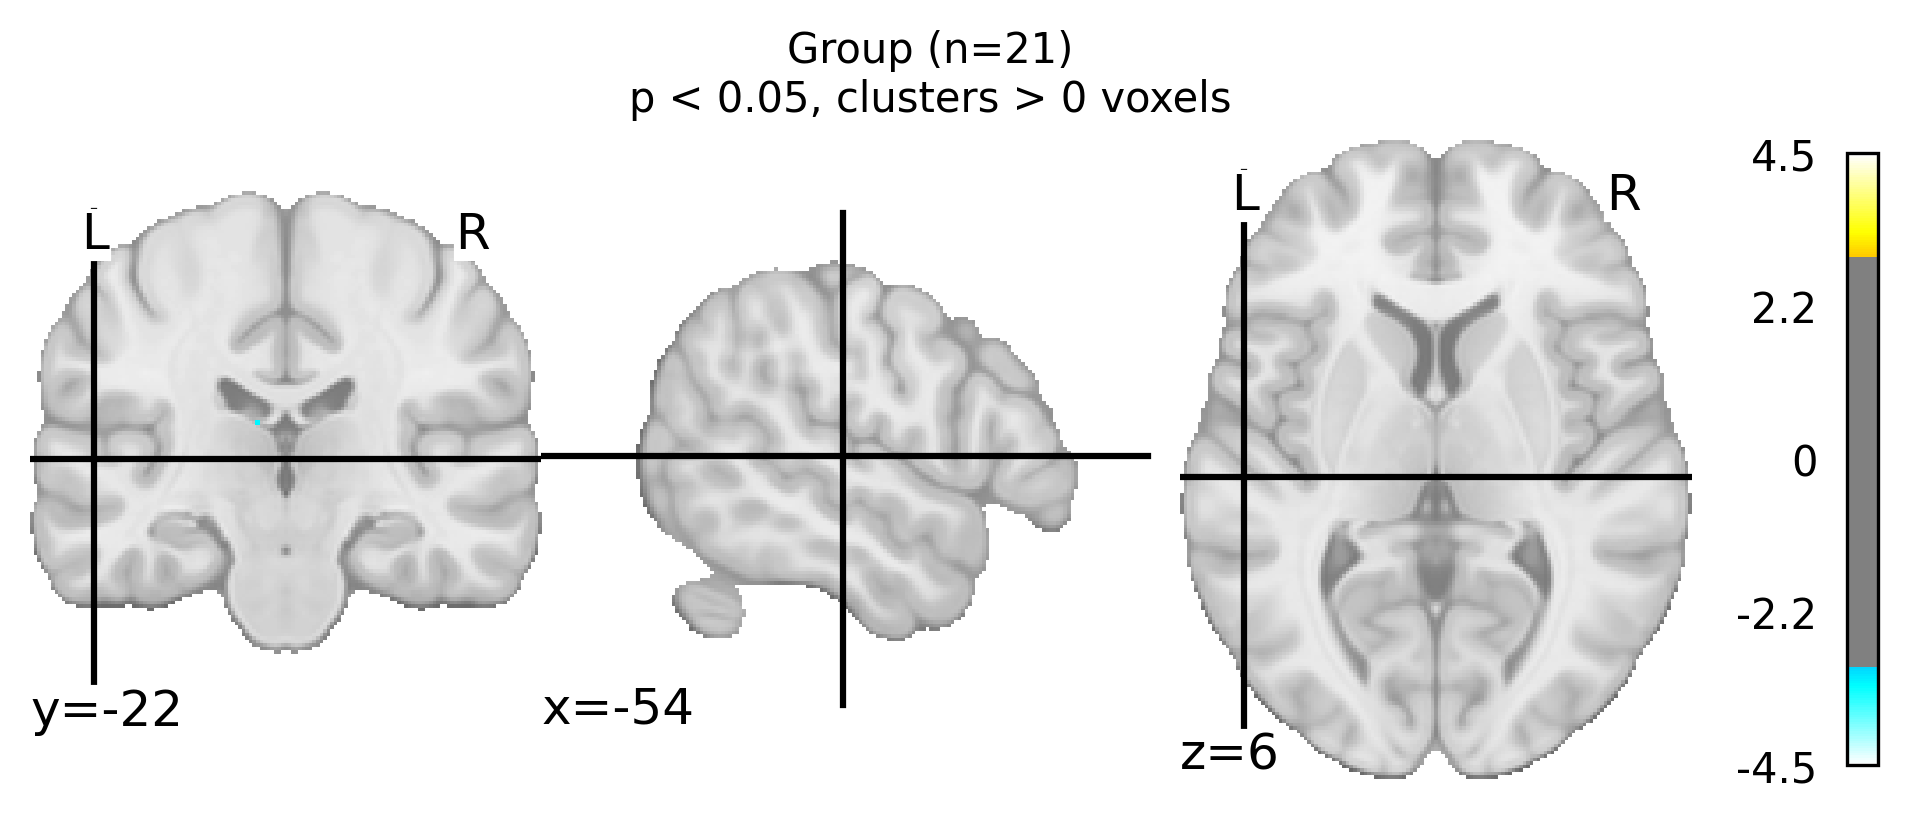

In [75]:
fig, ax = plt.subplots(figsize=(8,3), dpi=300)

plotting.plot_stat_map(
    thresholded_map, 
    threshold=zthresh,
    bg_img=mni152_template,
    black_bg=False,
    cut_coords=[-54, -22, 6],
    #display_mode='mosaic',
    #title=plot_title,
    axes=ax)
fig.suptitle(plot_title, fontsize=10);
print('The %s=%.3g threshold is %.3g' %(cluster_correct, alpha, zthresh))
#fig.savefig(os.path.join(group_out_dir,
#                     'group-Mand_space-{}_contrast-{}_view-ortho.png'.format(space_label, contrast_label)))

The None=0.05 threshold is 3


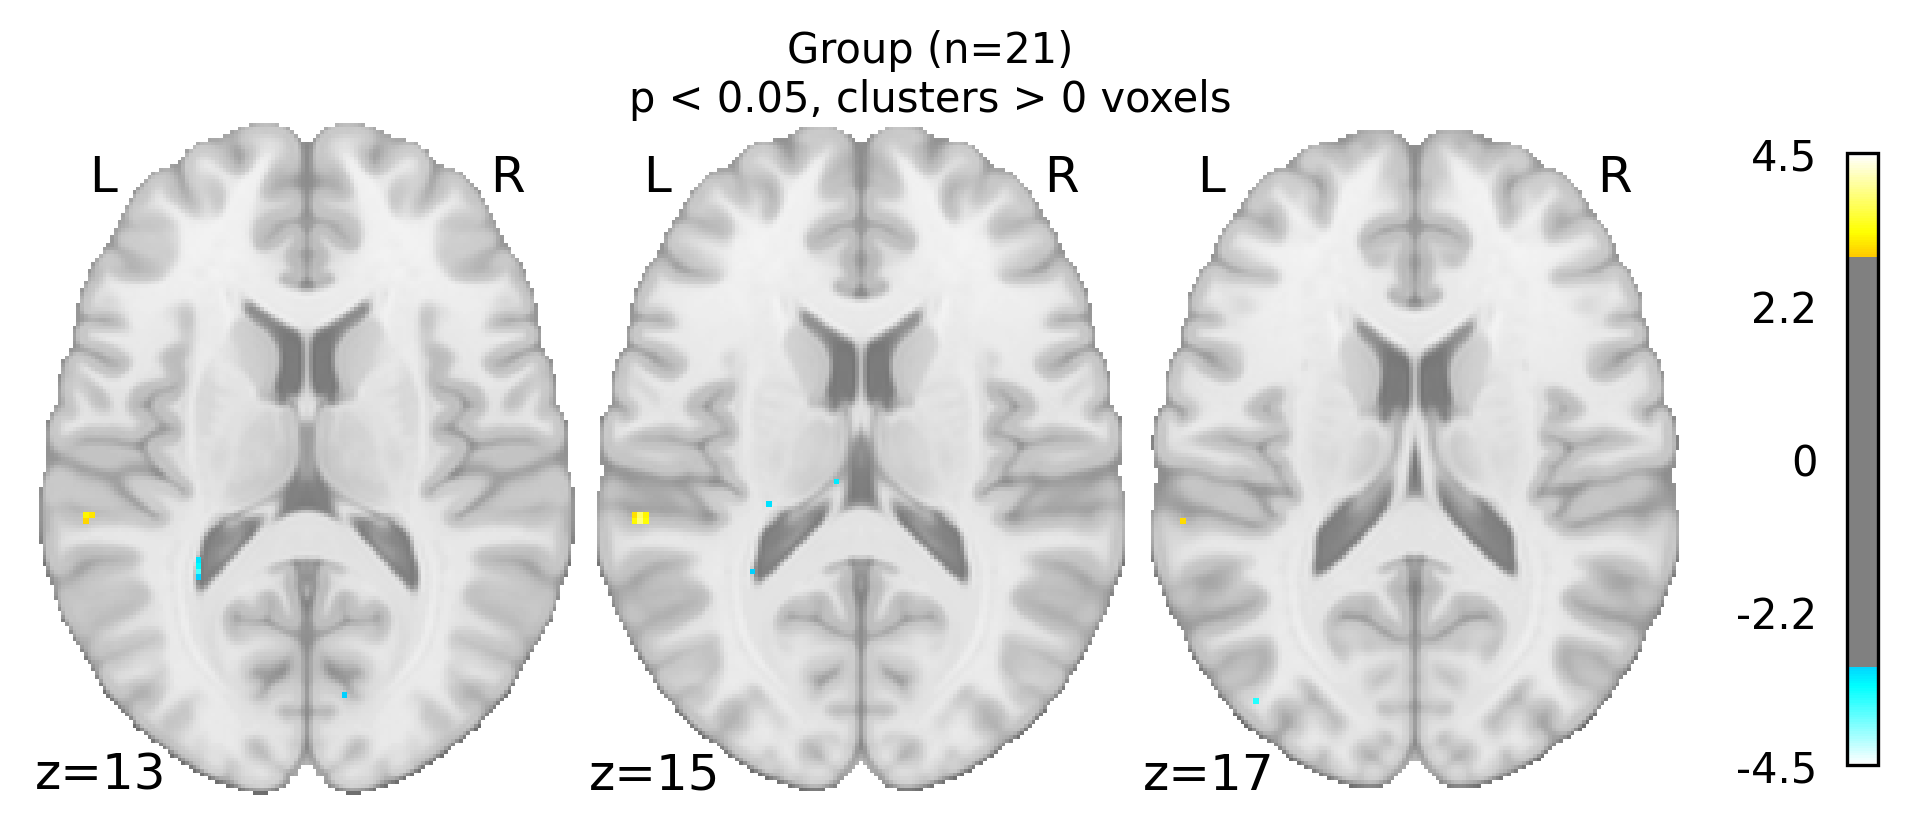

In [82]:
fig, ax = plt.subplots(figsize=(8,3), dpi=300)

plotting.plot_stat_map(
    thresholded_map, 
    threshold=zthresh,
    bg_img=mni152_template,
    black_bg=False,
    cut_coords=[13, 15, 17,],
    display_mode='z',
    #title=plot_title,
    axes=ax)
fig.suptitle(plot_title, fontsize=10);
print('The %s=%.3g threshold is %.3g' %(cluster_correct, alpha, zthresh))
#fig.savefig(os.path.join(group_out_dir,
#                     'group-Mand_space-{}_contrast-{}_view-ortho.png'.format(space_label, contrast_label)))

Interactive viewer:

/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



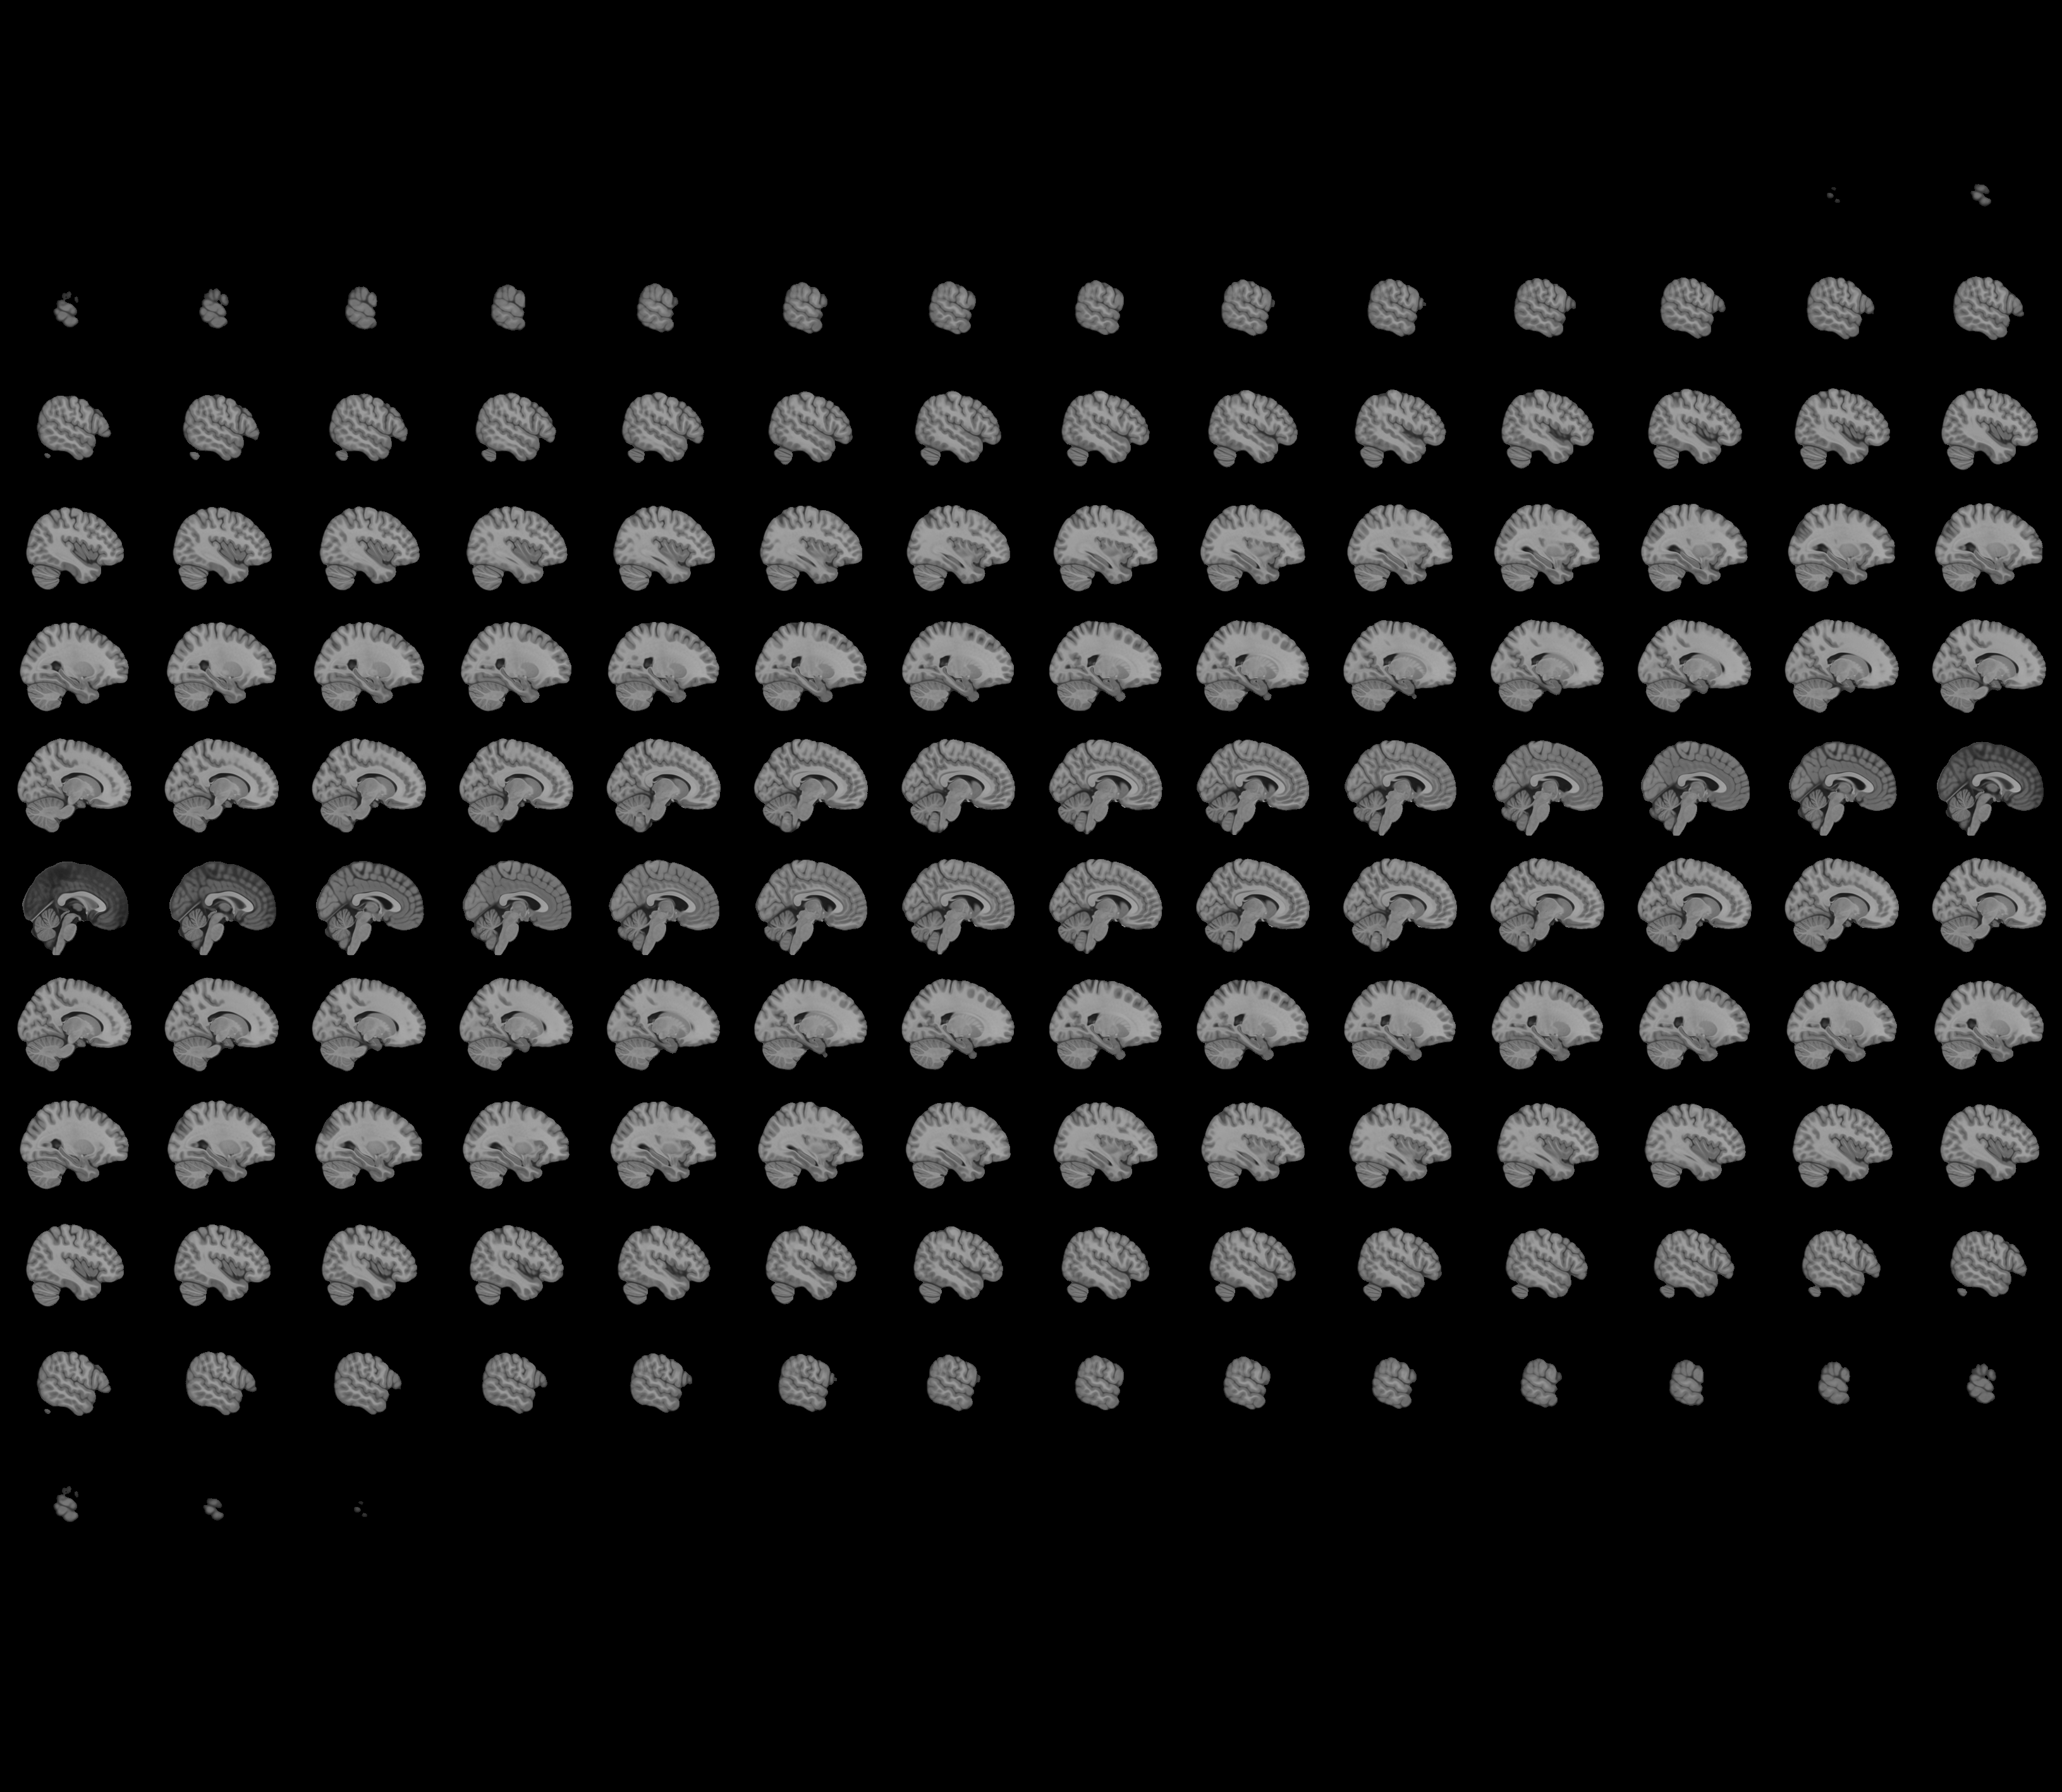
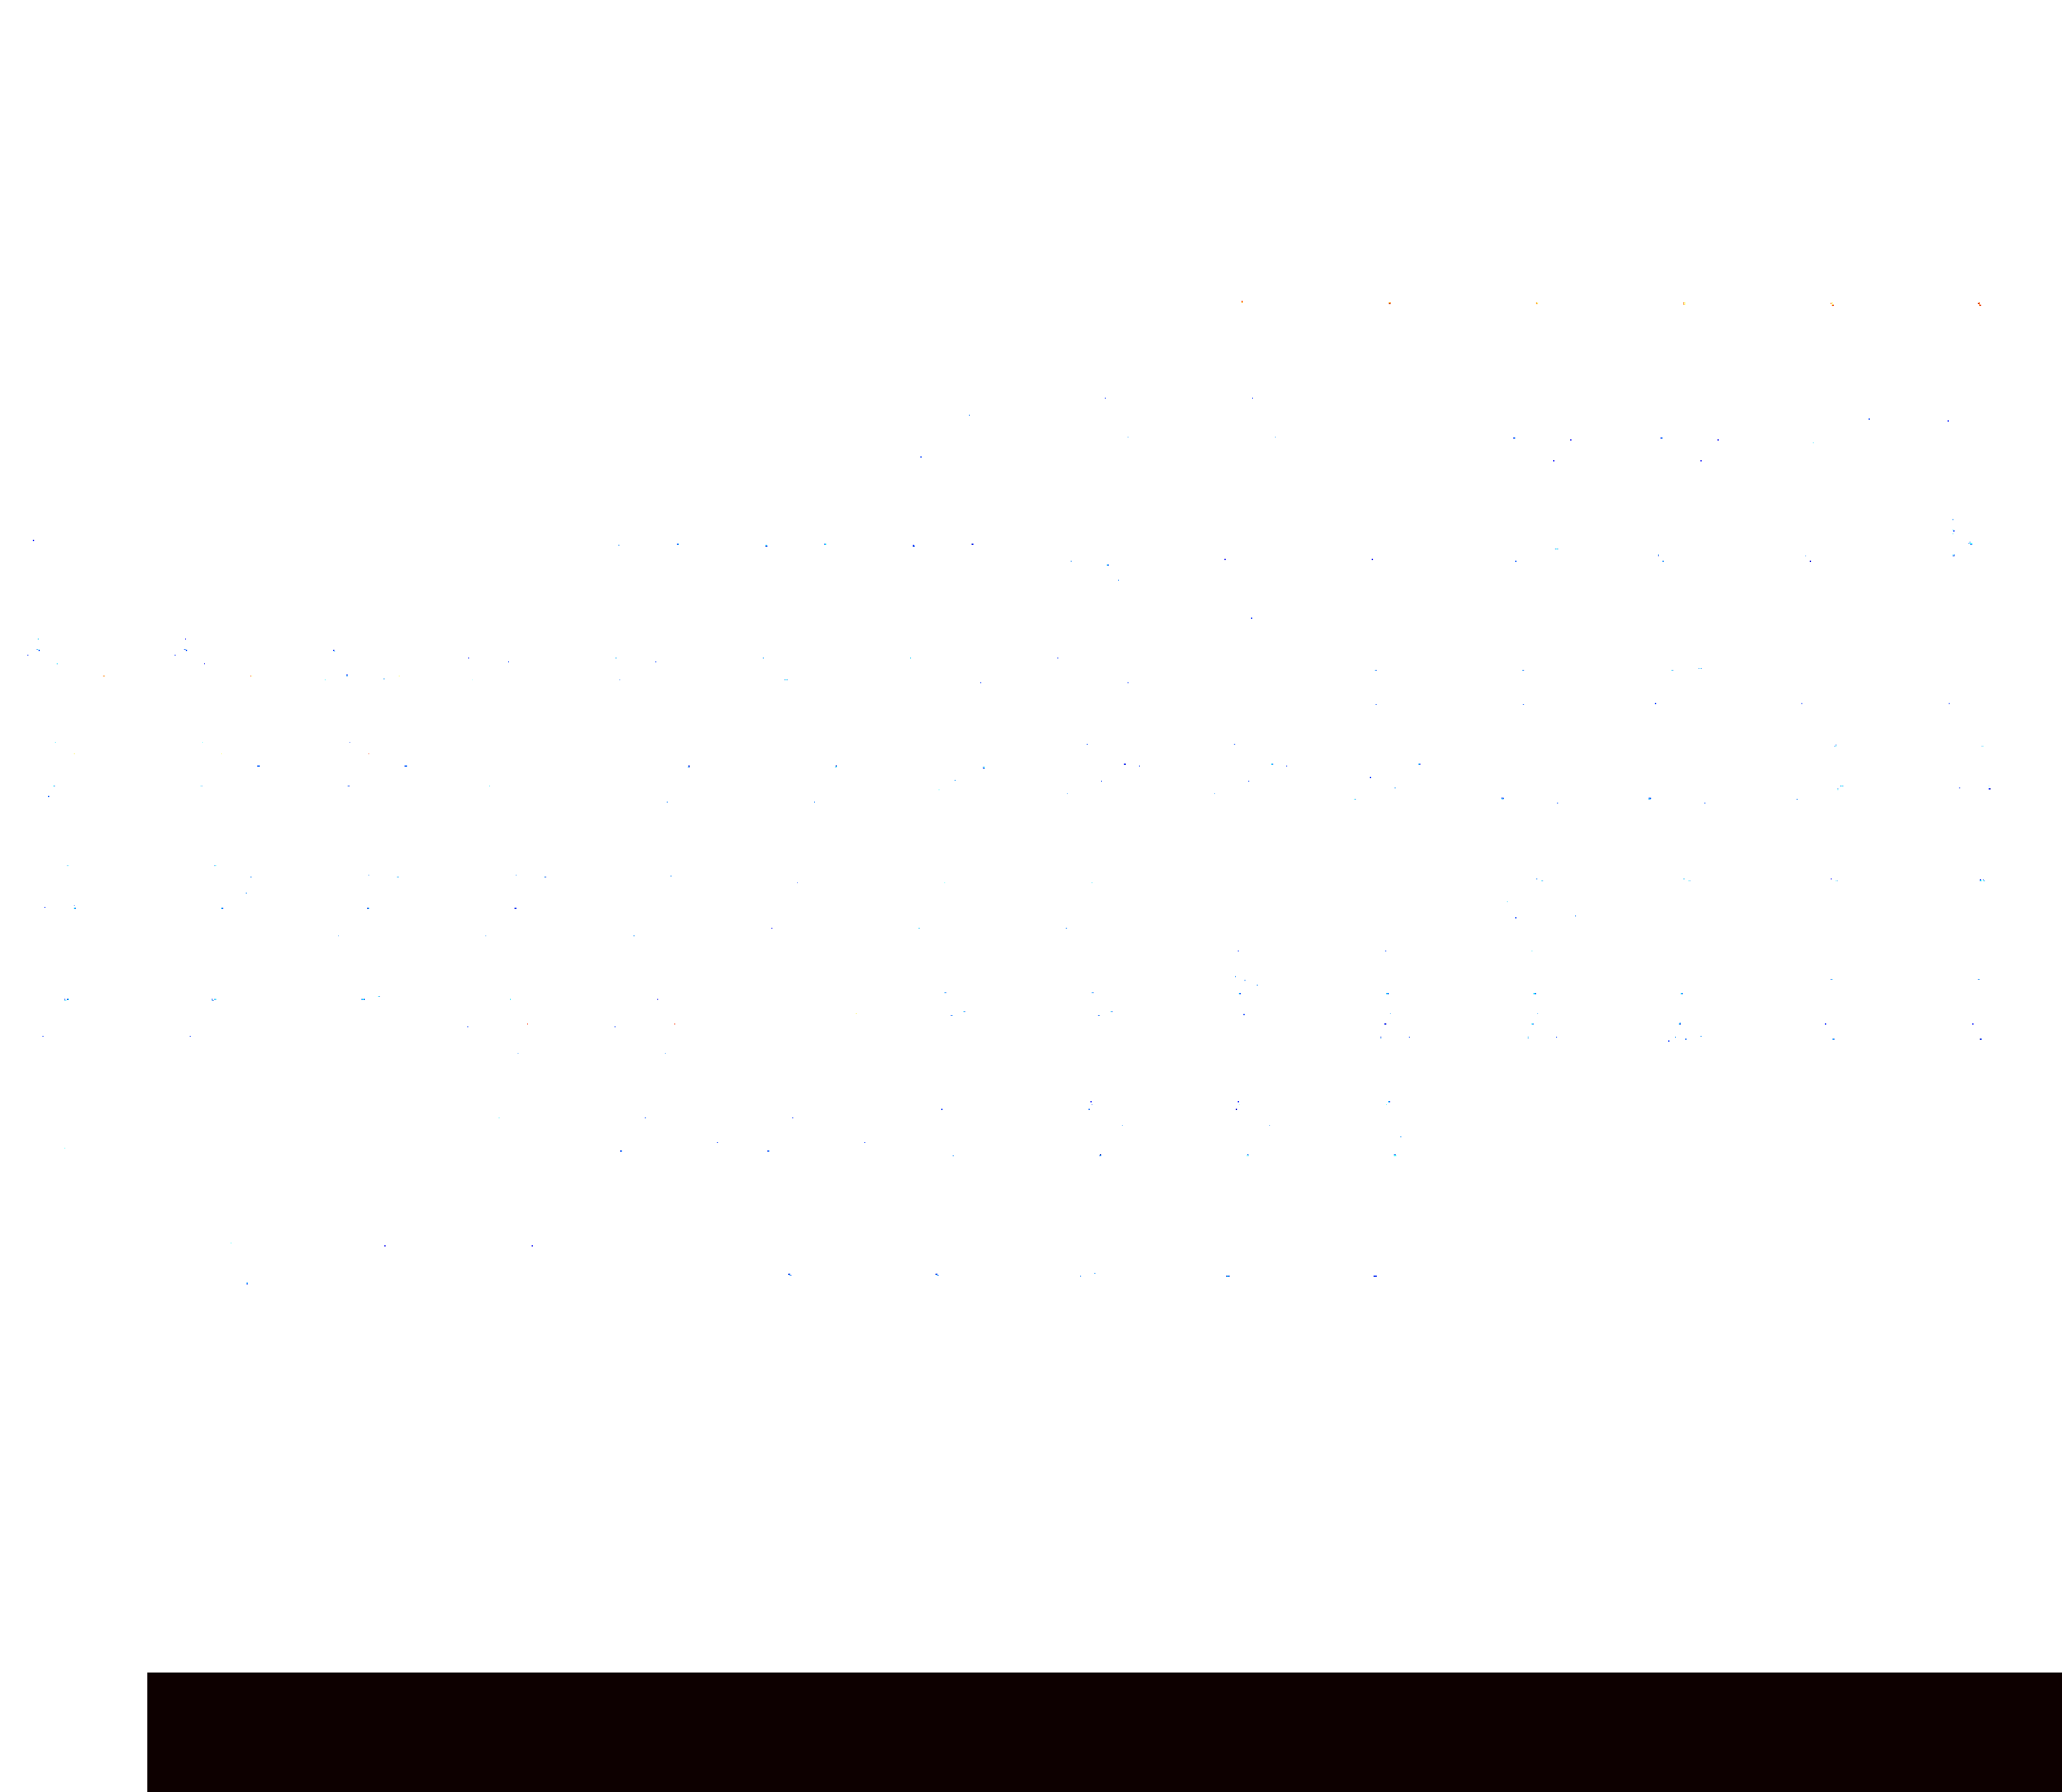

In [76]:
plotting.view_img(thresholded_map, 
                  threshold=zthresh, 
                  bg_img=mni152_template,
                  cut_coords=[-54, -22, 6],
                  title='')

Test lower threshold:

/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



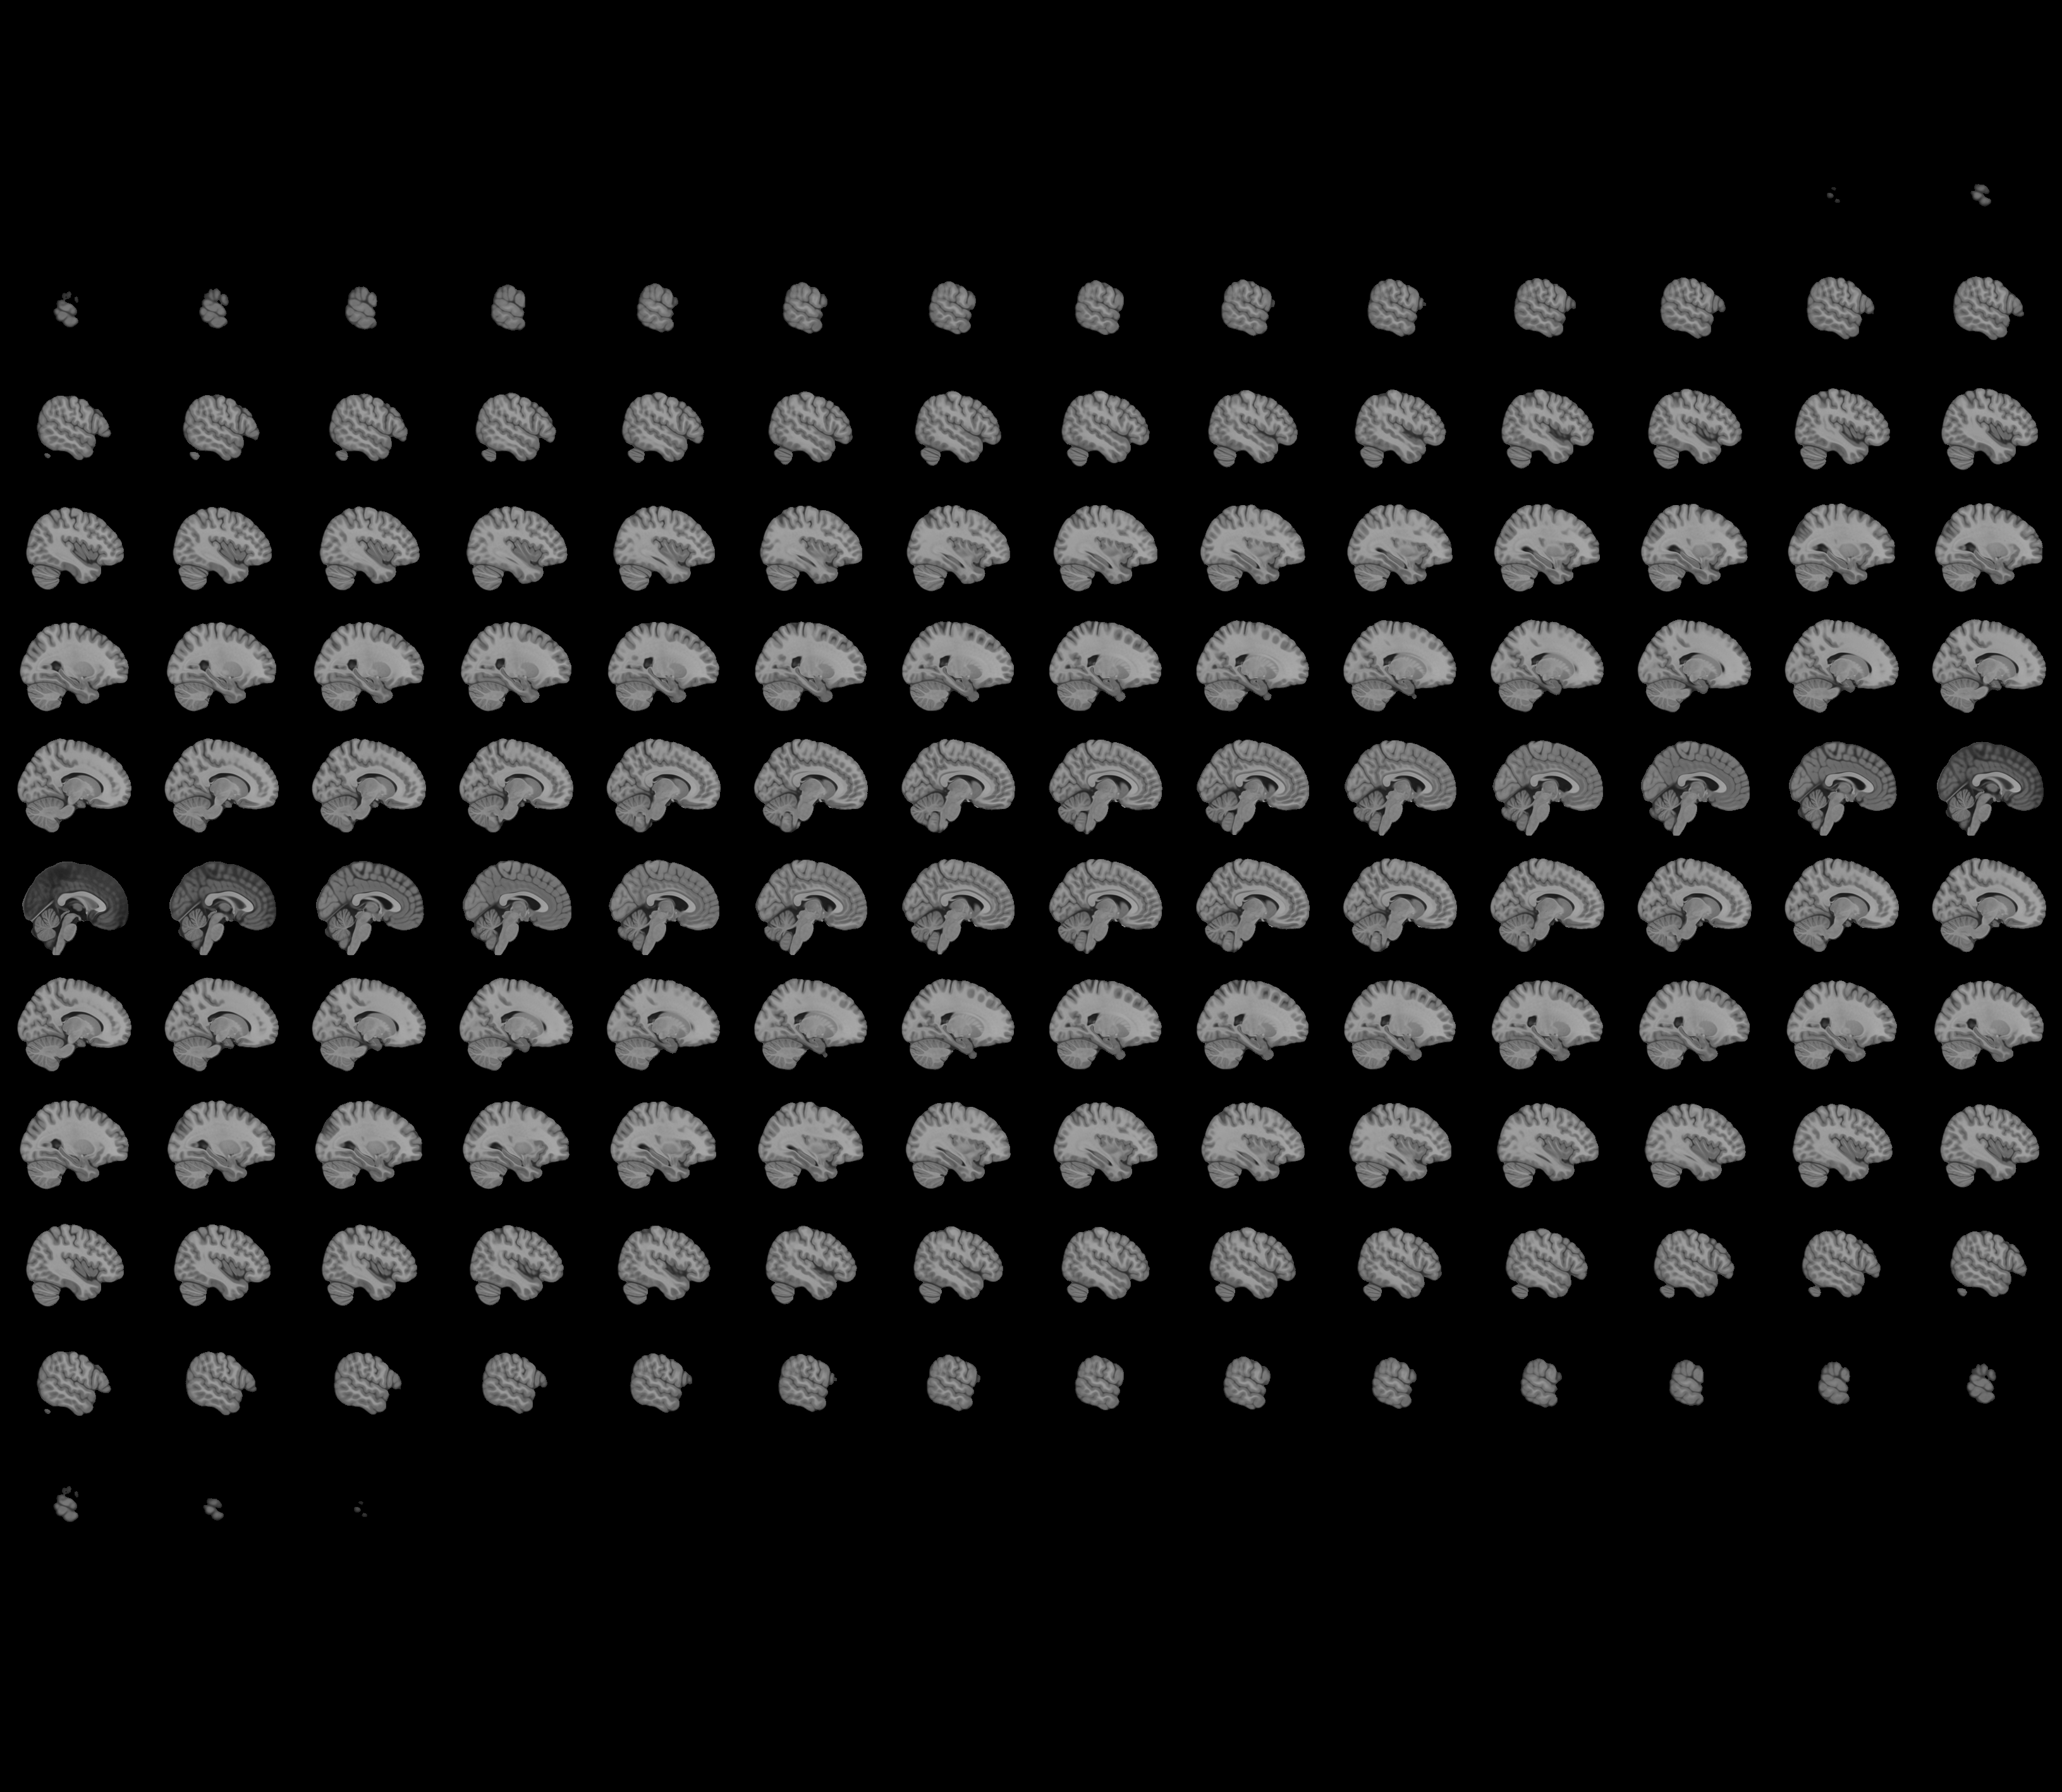
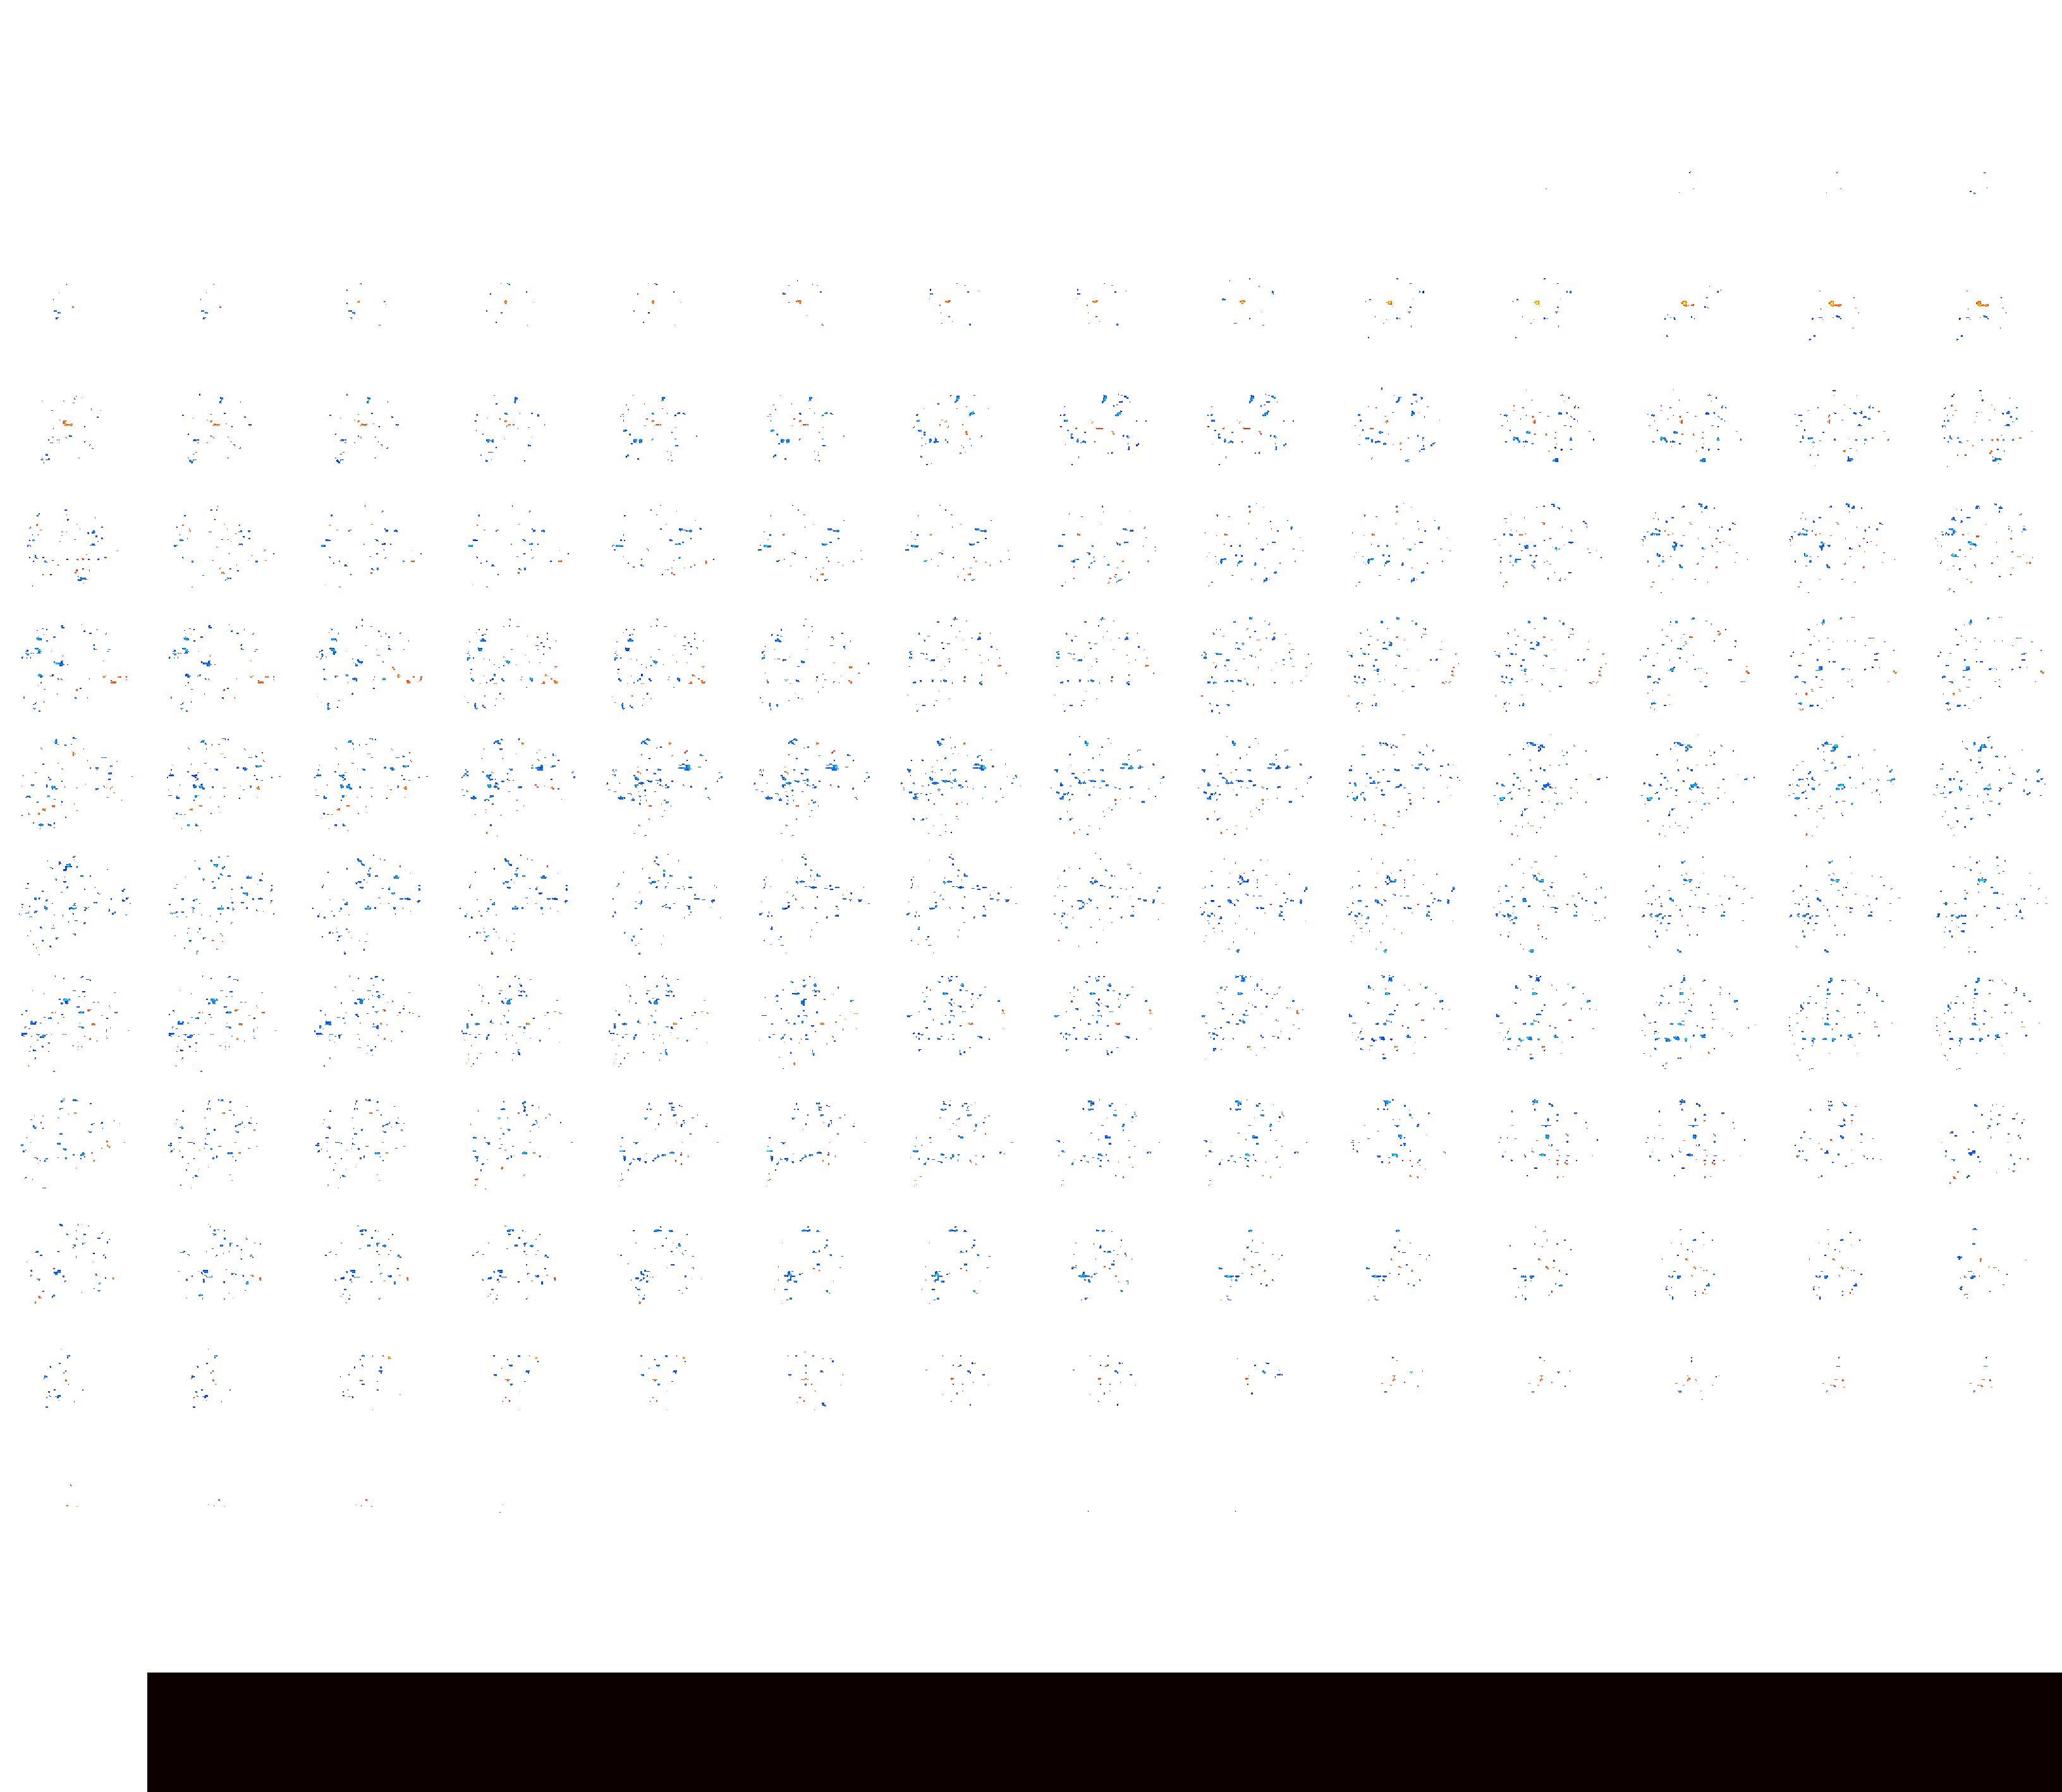

In [57]:
plotting.view_img(z_map, 
                  threshold=2, 
                  bg_img=mni152_template,
                  cut_coords=[-54, -22, 6],
                  title='')

#### Surface plots:

Group (n=21)
p < 0.05, clusters > 0 voxels


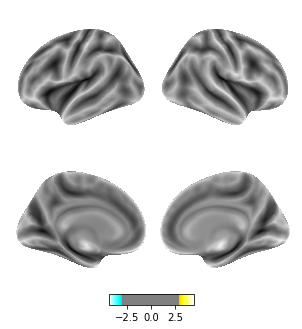

In [58]:
print(plot_title)
plotting.plot_img_on_surf(thresholded_map,
                          surf_mesh='fsaverage',
                          views=['lateral', 'medial'],
                          hemispheres=['left', 'right'],
                          inflate=True,
                          threshold=zthresh,
                          colorbar=True,)
plotting.show()

#### High-res pial surface

In [ ]:
fig2, axes2 = plt.subplots(nrows=2, ncols=2, subplot_kw={"projection": "3d"}, figsize=(5,3), dpi=300)
fig2.suptitle(plot_title, fontsize=10);

texture_left = surface.vol_to_surf(thresholded_map, fsaverage.pial_left)
texture_right = surface.vol_to_surf(thresholded_map, fsaverage.pial_right)

# left hemisphere lateral view
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, hemi='left',
                            #title='{} group – {} contrast'.format(group, contrast),
                            vmax=6,
                            colorbar=False,
                            threshold=zthresh, 
                            view='lateral',
                            bg_map=fsaverage.sulc_left, 
                            axes=axes2[0,0], 
                            fig=fig2
                            )

# right hemisphere lateral view
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, hemi='right',
                            #title='{} group – {} contrast'.format(group, contrast),
                            #colorbar=True,
                            vmax=6,
                            colorbar=False,
                            threshold=zthresh, 
                            view='lateral',
                            bg_map=fsaverage.sulc_right, 
                            axes=axes2[0,1], 
                            fig=fig2
                            )

# left hemisphere medial view
plotting.plot_surf_stat_map(fsaverage.infl_left, texture_left, hemi='left',
                            #title='{} group – {} contrast'.format(group, contrast),
                            vmax=6,
                            colorbar=False,
                            threshold=zthresh, 
                            view='medial',
                            bg_map=fsaverage.sulc_left, 
                            axes=axes2[1,0], 
                            fig=fig2
                            )

# right hemisphere medial view
plotting.plot_surf_stat_map(fsaverage.infl_right, texture_right, hemi='right',
                            #title='{} group – {} contrast'.format(group, contrast),
                            #colorbar=True,
                            vmax=6,
                            colorbar=False,
                            threshold=zthresh, 
                            view='medial',
                            bg_map=fsaverage.sulc_right, 
                            axes=axes2[1,1], 
                            fig=fig2
                            )
fig2.tight_layout()
fig2.show()
fig2.savefig(os.path.join(group_out_dir,
                     'group-Mand_space-{}_contrast-{}_view-surface.png'.format(space_label, contrast_label)))

#### High-res subcortical slices

In [ ]:
fig1, ax1 = plt.subplots(figsize=(5,2), dpi=300)
plotting.plot_stat_map(thresholded_map,
                       bg_img=mni152_template,
                       threshold=zthresh,
                       vmax=6,
                       cut_coords=[-10, -4, 2, 8, 14],
                       display_mode='z',
                       colorbar=False, 
                       draw_cross=False, 
                       black_bg=False,
                       axes=ax1)
fig1.savefig(os.path.join(group_out_dir,
                     'group-Mand_space-{}_contrast-{}_view-axial-subcort.png'.format(space_label, contrast_label)))

### NOT UPDATED: Group differences

In [47]:
second_level_model = SecondLevelModel(smoothing_fwhm=3).fit(l1_fnames_groupdiff, design_matrix=design_mat_groupdiff)

z_map = second_level_model.compute_contrast(second_level_contrast=[1, -1], output_type='z_score')

In [60]:
# threshold the second-level stats image
alpha = 0.05
cthresh = 10
cluster_correct = None # 'fdr' # 

thresholded_map, zthresh = threshold_stats_img(
                            z_map,
                            alpha=alpha,
                            height_control=cluster_correct,
                            cluster_threshold=cthresh,
                            two_sided=True,
                        )

In [61]:
group_label = 'Mand-vs-NMan'
z_fpath   = os.path.join(group_out_dir,
                         'group-{}_space-{}_contrast-{}_LSS_map-zstat.nii.gz'.format(group_label, space_label, contrast_label))
thr_fpath = os.path.join(group_out_dir,
                         'group-{}_space-{}_contrast-{}_LSS_alpha-{}_correct-{}_cthresh-{}_map-zstat.nii.gz'.format(group_label, space_label, 
                                                                                                                contrast_label, alpha, 
                                                                                                                cluster_correct, cthresh))

nib.save(z_map, z_fpath)
nib.save(thresholded_map, thr_fpath)

In [62]:
plot_title = ('Mand (n=%d) vs. NMan (n=%d) group differences\n'
              '%s > baseline %s-corrected z map \n'
              'p < %.02f, clusters > %d voxels'%(len(sub_list_mand), len(sub_list_nman), 
                                                 contrast_label, cluster_correct, alpha, cthresh))

In [ ]:
fig, ax = plt.subplots(figsize=(8,3), dpi=300)

plotting.plot_stat_map(
    thresholded_map, 
    threshold=zthresh,
    bg_img=mni152_template,
    black_bg=False,
    cut_coords=[-54, -22, 6],
    #display_mode='mosaic',
    #title=plot_title,
    axes=ax)
fig.suptitle(plot_title, fontsize=10);
print('The %s=%.3g threshold is %.3g' %(cluster_correct, alpha, zthresh))
#fig.savefig(os.path.join(group_out_dir,
#                     'group-{}_space-{}_contrast-{}_view-ortho.png'.format(group_label, space_label, contrast_label)))

Interactive viewer:

In [ ]:
plotting.view_img(z_map, #thresholded_map, 
                  threshold=2., # threshold
                  bg_img=mni152_template,
                  cut_coords=[-54, -22, 6],
                  title='Mand > NMan sound > baseline')